Inertia: 660.2141

Jumlah data per cluster:
cluster_label
cluster_0     1
cluster_1    35
cluster_2     1
Name: count, dtype: int64

Rata-rata per cluster:
                 abs_energy         auc  autocorr  average_power  \
cluster_label                                                      
cluster_0      4.319000e+00     148.018    27.000          0.001   
cluster_1      3.020000e-01      10.292     3.543          0.001   
cluster_2      4.647580e+08  379752.228     5.000    1273309.564   

               calc_centroid  calc_max  calc_mean  calc_median  calc_min  \
cluster_label                                                              
cluster_0           2590.430     0.038      0.029        0.029     0.020   
cluster_1            180.032     0.037      0.029        0.029     0.021   
cluster_2            173.116  2132.111   1039.284      928.475   321.460   

               calc_std  ...  spectral_spread  spectral_variation  \
cluster_label            ...                         

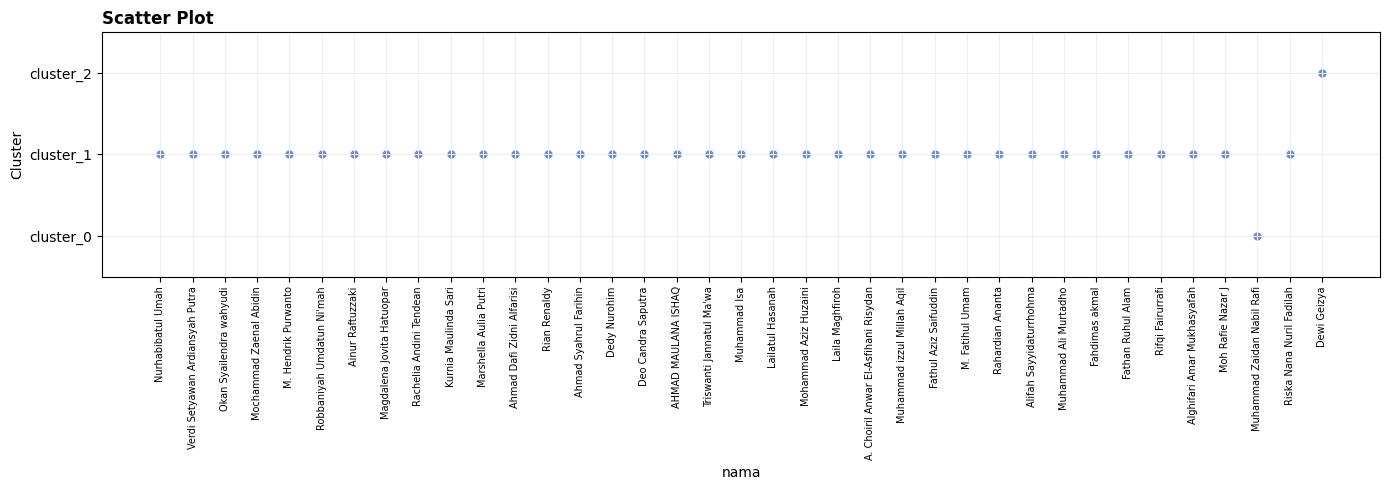


Hasil disimpan ke hasil_clustering.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ===================== PENGATURAN =====================
CSV_PATH = "ekstraksi_fitur_co.csv"                       # lokasi file CSV Anda
KOLOM_NAMA = "nama"                         # kolom label untuk sumbu X
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()        # kolom numerik yang di-cluster
K = 3                                       # jumlah cluster (bebas Anda tentukan)
GUNAKAN_SCALING = True                      # False jika tidak ingin distandarisasi
# ======================================================

# 1. Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()

# 2. Standarisasi (opsional)
if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# 3. K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# 4. Hasil di terminal
print(f"Inertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())
print("\nRata-rata per cluster:")
print(data.groupby("cluster_label")[KOLOM_FITUR].mean().round(3))

# 5. Scatter plot: nama (sumbu X) vs cluster (sumbu Y)
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()

# 6. Simpan hasil ke CSV
data.drop(columns="cluster_label").to_csv("hasil_clustering.csv", index=False)
print("\nHasil disimpan ke hasil_clustering.csv")

PCA: 68 fitur -> 37 dimensi
  PC1: 53.95% varians
  PC2: 23.67% varians
  PC3: 6.06% varians
  PC4: 3.85% varians
  PC5: 2.93% varians
  PC6: 1.88% varians
  PC7: 1.66% varians
  PC8: 1.18% varians
  PC9: 1.05% varians
  PC10: 0.80% varians
  PC11: 0.68% varians
  PC12: 0.56% varians
  PC13: 0.46% varians
  PC14: 0.34% varians
  PC15: 0.25% varians
  PC16: 0.18% varians
  PC17: 0.13% varians
  PC18: 0.12% varians
  PC19: 0.07% varians
  PC20: 0.07% varians
  PC21: 0.05% varians
  PC22: 0.02% varians
  PC23: 0.01% varians
  PC24: 0.01% varians
  PC25: 0.01% varians
  PC26: 0.00% varians
  PC27: 0.00% varians
  PC28: 0.00% varians
  PC29: 0.00% varians
  PC30: 0.00% varians
  PC31: 0.00% varians
  PC32: 0.00% varians
  PC33: 0.00% varians
  PC34: 0.00% varians
  PC35: 0.00% varians
  PC36: 0.00% varians
  PC37: 0.00% varians
  Total: 100.00% varians dipertahankan

Inertia: 660.2141

Jumlah data per cluster:
cluster_label
cluster_0     1
cluster_1    35
cluster_2     1
Name: count, dtype:

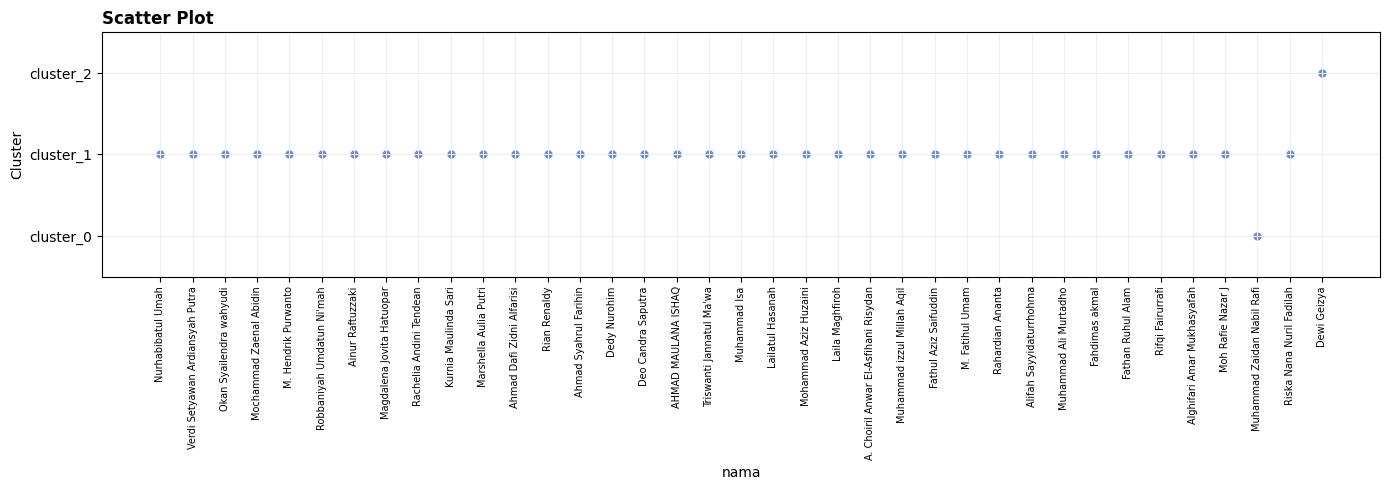

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "ekstraksi_fitur_co.csv"               
KOLOM_NAMA = "nama"                               
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 3
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")
for i, r in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {r * 100:.2f}% varians")
print(f"  Total: {pca.explained_variance_ratio_.sum() * 100:.2f}% varians dipertahankan")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()
